## Setup

In [12]:
import sys
from pathlib import Path

# notebooks/ -> repo root
REPO_ROOT = Path.cwd().resolve()
print(REPO_ROOT)
sys.path.insert(0, str(REPO_ROOT))

/Users/tzhang04/Desktop/active-passive-alternations/notebooks


In [60]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from scipy.stats import normaltest, ttest_rel
from sklearn.preprocessing import StandardScaler
from IPython.display import Markdown, display

In [69]:
# Configure plot settings

from re import X
import matplotlib.pyplot as plt
import matplotlib.font_manager
from matplotlib.markers import MarkerStyle
from matplotlib.ticker import FormatStrFormatter, ScalarFormatter, LogFormatter
from matplotlib import rc
import matplotlib.gridspec as gridspec
import warnings


warnings.filterwarnings("ignore")

factuality_cmap = {
    True: "#7EACB5",
    False: "#BF4646",
}

metrics = [
    'surp_mean', # Mean surprisal
    'surp_slor', # SLOR
    'uid_std', # Std. of surprisal
    'uid_mad', # mean avg. deviation of surprisal
    'uid_pwd', # Local variance (pairwise euc. distance)
    'uid_range', # Range of surprisal
    'uid_slope', # Slope of a linear function fit to surp values
]

metrics_formatted = [
    'Surp. Mean',
    'SLOR',
    'Surp. STD',
    'Surp. MAD',
    'Local Var.',
    'Surp. Range',
    'LinReg Slope',
]

metrics_mapping = dict(zip(metrics, metrics_formatted))
# metrics_cmap = dict(zip([
#     'surp_slor', ''
# ]))

sns.set_palette("Set2")
# sns.set(rc={
#     'axes.facecolor':'#e5d9b6', 
#     'figure.facecolor':'#e5d9b6'
# })
# Font
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": "Times",
})

In [15]:
data_path = "../outputs/cf_word_sentence_uid.csv"
uid_df = pd.read_csv(data_path).iloc[:, 1:]

In [41]:
_, uid_unit, uid_level, _ = Path(data_path).stem.split("_")
context_lvl = 'document'
plot_suffix = f"_{uid_unit}_{uid_level}_{context_lvl}"

In [42]:
def extract_sents_of_interest(doc_sents: pd.DataFrame):
    converted_indices = doc_sents['conv_idx'].unique()
    sents_of_interest = []
    for i, sent in doc_sents.iterrows():
        if ((sent['sent_idx'] in converted_indices)
            and 
            (sent['conv_idx'] in [sent['sent_idx'], -1])):
            sents_of_interest.append(sent)
    return pd.DataFrame(sents_of_interest)

def check_passive(f_cf_pair: pd.DataFrame):
    conversion = f_cf_pair['conversion'].unique()
    if 'a>p' in conversion:
        return f_cf_pair.assign(passive=[False if fact else True for fact in f_cf_pair['factual']])
    elif 'p>a' in conversion:
        return f_cf_pair.assign(passive=[True if fact else False for fact in f_cf_pair['factual']])

In [43]:
uid_df[['factual', 'doc_name', 'conv_idx', 'conversion']] = uid_df['doc_id'].str.split("::", expand=True)
uid_df['conv_idx'] = uid_df['conv_idx'].astype(int)

In [44]:
uid_df['context'].unique()

<StringArray>
[    'sentence',        'prev1',        'prev3',     'document',
  'sent[-2,+0]',  'sent[-2,+2]',  'tok[-64,+0]', 'tok[-64,+64]']
Length: 8, dtype: str

In [45]:
sents_of_interest = uid_df.groupby("doc_name").apply(extract_sents_of_interest).reset_index().drop(columns="level_1")
sents_of_interest.shape

(39040, 17)

In [46]:
cf_comparison = sents_of_interest[sents_of_interest['context']==context_lvl]
cf_comparison['factual'] = cf_comparison['factual'] == 'f'
cf_comparison = cf_comparison.groupby(['doc_id', 'sent_idx']).first().sort_values(by=['doc_name', 'sent_idx']).reset_index()
cf_comparison = cf_comparison.groupby(['doc_name', 'sent_idx']).filter(lambda g: g.shape[0] > 1)
cf_comparison = cf_comparison.groupby(['doc_name', 'sent_idx']).apply(check_passive).reset_index()
cf_comparison.head()

,doc_name,sent_idx,level_2,doc_id,context,sentence,surp_mean,surp_slor,uid_std,uid_mad,uid_pwd,uid_range,uid_cv,uid_slope,uid_len,factual,conv_idx,conversion,passive
0,GUM_academic_art,8,0,cf::GUM_academic_art::8::a>p,document,Do museum labels have an impact on how people ...,5.596717,4.437688,4.964347,4.370365,18.115661,13.969358,0.887010,-0.897886,12,False,8,a>p,True
1,GUM_academic_art,8,1,f::GUM_academic_art::-1::og,document,Do museum labels have an impact on how people ...,5.596717,4.437688,4.964347,4.370365,18.115661,13.969358,0.887010,-0.897886,12,True,-1,og,False
2,GUM_academic_art,11,2,cf::GUM_academic_art::11::a>p,document,A collaborative pilot project focusing on a un...,8.397016,2.723669,8.769274,5.802251,204.251054,39.907106,1.044332,-0.015118,19,False,11,a>p,True
3,GUM_academic_art,11,3,f::GUM_academic_art::-1::og,document,This paper describes a collaborative pilot pro...,8.279072,3.236220,8.889991,5.762708,200.754222,39.123034,1.073791,0.464200,17,True,-1,og,False
4,GUM_academic_art,16,4,cf::GUM_academic_art::16::a>p,document,The potential implications of these techniques...,6.231897,4.202044,3.934182,3.250515,24.923332,15.087298,0.631298,0.002615,22,False,16,a>p,True


In [47]:
standard_scaler = StandardScaler()
cf_comparison[metrics] = standard_scaler.fit_transform(cf_comparison[metrics])

## Plots

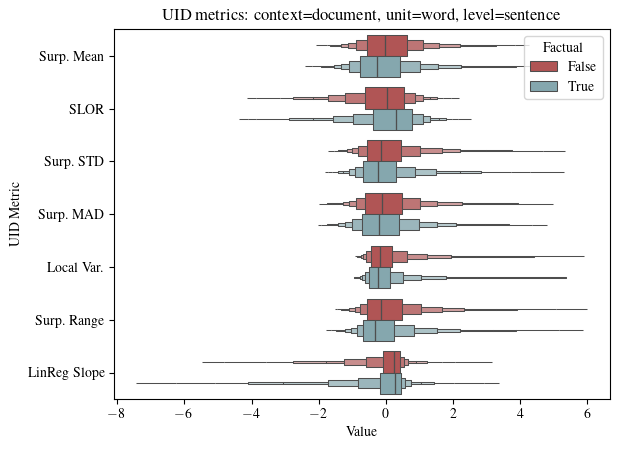

In [79]:
fig, ax = plt.subplots()
sns.boxenplot(data=cf_comparison.melt(
       id_vars=['factual'],
       value_vars=metrics,
       var_name='UID Metric',
       value_name='Value'
       ),
        hue='factual', x='Value', y='UID Metric', ax=ax, palette=factuality_cmap,
        showfliers=False)
plt.title(f"UID metrics: context={context_lvl}, unit={uid_unit}, level={uid_level}")
handles, labels = ax.get_legend_handles_labels()
plt.legend(title="Factual")
ax.set_yticks(ticks=metrics, labels=metrics_formatted)
fig.savefig("../plots/uid_metrics" + plot_suffix,
            dpi=200, bbox_inches='tight')

In [26]:
pw_diffs = (cf_comparison
            .sort_values(by='factual') # Always Factual - Counterfactual
            .groupby(['doc_name','sent_idx'])
            [metrics]
            .apply(
                lambda g: g.diff().iloc[1] if g.shape[0] > 1 else None
                )
            .reset_index())
pw_diffs

,doc_name,sent_idx,surp_mean,surp_slor,uid_std,uid_mad,uid_pwd,uid_range,uid_slope
0,GUM_academic_art,8,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,GUM_academic_art,11,-0.060938,0.257940,0.071232,-0.031761,-0.057022,-0.101221,0.538265
2,GUM_academic_art,16,-0.096035,0.017619,0.106847,-0.061610,0.030320,0.004548,0.191935
3,GUM_academic_art,17,-0.125248,0.313225,-0.330585,-0.212285,-0.004976,-0.776601,0.044467
4,GUM_academic_art,20,-0.272233,0.185716,-0.228783,-0.179756,-0.112281,-0.227514,0.042358
...,...,...,...,...,...,...,...,...,...
2434,GUM_whow_skittles,50,-0.958085,1.139512,0.421567,0.760529,0.151464,-0.049825,0.082159
2435,GUM_whow_skittles,51,-0.000622,0.000606,-0.000163,-0.000157,0.000029,-0.002050,0.000336
2436,GUM_whow_skittles,52,-0.191273,0.241414,0.068540,0.093599,0.146643,-0.156336,0.037651
2437,GUM_whow_skittles,53,-0.295958,0.367564,-0.169431,-0.003109,0.062476,-0.917087,0.070204


In [27]:
pw_diffs['uid_pwd'].median()

np.float64(-0.00020653987005225805)

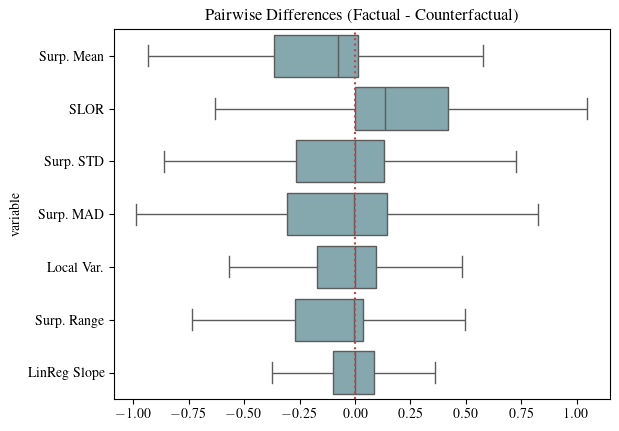

In [80]:
sns.boxplot((pw_diffs[['doc_name', 'sent_idx'] + metrics]
             .melt(id_vars=['doc_name', 'sent_idx'])), 
            x='value', y='variable', showfliers=False,
            color="#7EACB5")
plt.axvline(x=0, color='#BF4646', linestyle='dotted', zorder=5)
plt.title("Pairwise Differences (Factual - Counterfactual)")
plt.xlabel('')
plt.yticks(ticks=metrics, labels=metrics_formatted)
plt.savefig("../plots/pw_diffs_fact-counterfact" + plot_suffix,
            dpi=100, bbox_inches='tight')

In [51]:
def perm_test(data, 
              label_column, 
              value_column, 
              n_permutations, 
              agg_fn=np.mean, 
              test_stat=lambda a, b: np.abs(a - b),
              compare_fn=lambda sim, obs: sim >= obs):
    value_a, value_b = data[label_column].unique()
    print("Labels in order: ", value_a, value_b)
    obs_a = agg_fn(data.loc[data[label_column] == value_a, value_column])
    obs_b = agg_fn(data.loc[data[label_column] == value_b, value_column])
    obs_stat = test_stat(obs_a, obs_b)
    
    sim_stats = []
    for _ in range(n_permutations):
        sim_labels = np.random.permutation(data[label_column])
        sim_a = agg_fn(data.loc[sim_labels == value_a, value_column])
        sim_b = agg_fn(data.loc[sim_labels == value_b, value_column])
        sim_stat = test_stat(sim_a, sim_b)
        sim_stats.append(sim_stat)
    sim_stats = np.array(sim_stats)
    return obs_stat, sim_stats, (compare_fn(sim_stats, obs_stat)).mean()

In [81]:
results = []
for metric in metrics:
    obs, sim, p_val = perm_test(cf_comparison.sort_values('factual'), 
                            'factual', metric, 10000,
                            # test_stat=lambda a, b: b-a,
                            # compare_fn=lambda sim, obs: sim >= obs
                            )
    results.append({
        "Metric": metrics_mapping[metric],
        "P-value": p_val,
        "Observed abs. diff": obs,
        "Simulated abs. diff": sim
    })
results = pd.DataFrame(results)

Labels in order:  False True
Labels in order:  False True
Labels in order:  False True
Labels in order:  False True
Labels in order:  False True
Labels in order:  False True
Labels in order:  False True


In [83]:
output_name = "../plots/diff_means_perm" + plot_suffix + ".md"
(results.drop(columns="Simulated abs. diff")
 .round(decimals=2)
 .set_index("Metric")
 .to_markdown(buf=output_name))
with open(output_name, 'r', encoding='utf-8') as fh:
    content = fh.read()
display(Markdown(content))

| Metric       |   P-value |   Observed abs. diff |
|:-------------|----------:|---------------------:|
| Surp. Mean   |      0    |                 0.17 |
| SLOR         |      0    |                 0.22 |
| Surp. STD    |      0    |                 0.11 |
| Surp. MAD    |      0    |                 0.09 |
| Local Var.   |      0.03 |                 0.06 |
| Surp. Range  |      0    |                 0.17 |
| LinReg Slope |      0    |                 0.09 |

In [84]:
results = []
for metric in metrics:
    metric_diffs = pw_diffs[metric]
    normal_res = normaltest(metric_diffs)
    factuals = cf_comparison.loc[cf_comparison['factual']]
    cfactuals = cf_comparison.loc[~cf_comparison['factual']]
    ttest_res = ttest_rel(factuals[metric], cfactuals[metric],
                          alternative="less"
                          )
    results.append({
        'Metric': metrics_mapping[metric],
        'Normality TS': normal_res.statistic,
        'Normality P-val': normal_res.pvalue,
        'Paired-t TS': ttest_res.statistic,
        'Paired-t P-val': ttest_res.pvalue
    })
results = pd.DataFrame(results)

In [85]:
output_name = "../plots/norm_pairedt" + plot_suffix + ".md"
(results
 .round(decimals=2)
 .set_index("Metric")
 .to_markdown(buf=output_name))
with open(output_name, 'r', encoding='utf-8') as fh:
    content = fh.read()
display(Markdown(content))

| Metric       |   Normality TS |   Normality P-val |   Paired-t TS |   Paired-t P-val |
|:-------------|---------------:|------------------:|--------------:|-----------------:|
| Surp. Mean   |         381.67 |                 0 |        -16.27 |                0 |
| SLOR         |         382.49 |                 0 |         22.3  |                1 |
| Surp. STD    |         710.94 |                 0 |         -8.32 |                0 |
| Surp. MAD    |         433    |                 0 |         -6.27 |                0 |
| Local Var.   |         835.1  |                 0 |         -6.15 |                0 |
| Surp. Range  |         805.81 |                 0 |        -13.81 |                0 |
| LinReg Slope |        1312.9  |                 0 |         -4.76 |                0 |

In [ ]:
factual_passives_sample = cf_comparison[cf_comparison['passive'] & cf_comparison['factual']].sample(n=cf_comparison['factual'].sum(), replace=True)
factual_actives_sample = cf_comparison[~cf_comparison['passive'] & cf_comparison['factual']].sample(n=cf_comparison['factual'].sum(), replace=True)
pass_vs_act = pd.concat([factual_passives_sample, factual_actives_sample])

In [ ]:
results = []
metrics = ['surp_mean', 'uid_std', 'uid_mad']
for metric in metrics:
    obs, sim, p_val = perm_test(pass_vs_act, 'passive', metric, 10000,
                            test_stat=lambda a, b: b-a,
                            compare_fn=lambda sim, obs: sim >= obs)
    results.append({
        "metric": metric,
        "pval": p_val,
        "observed": obs,
        "simulated": sim
    })
results = pd.DataFrame(results)

Labels in order:  True False
Labels in order:  True False
Labels in order:  True False


In [ ]:
print(results[['metric', 'observed', 'pval']].to_markdown())

|    | metric    |   observed |   pval |
|---:|:----------|-----------:|-------:|
|  0 | surp_mean |  0.749491  |  0     |
|  1 | uid_std   |  0.0148145 |  0.373 |
|  2 | uid_mad   |  0.142569  |  0     |
